In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score,LeaveOneOut
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


In [2]:
data = pd.read_csv('F:/Dataset/Bank_Personal_Loan_Modelling(1).csv') 
data 

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [3]:
df=pd.DataFrame(data)

In [4]:
df1=pd.DataFrame(df)

In [5]:
df1['CCAvg'] = df1['CCAvg'].apply(lambda x: x.replace('/', '.')).astype(float)

In [6]:
df1['Experience'] = df1['Experience'].abs()

In [7]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.134600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.415189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [8]:
print("show missing value :",df.isnull().sum()) 

show missing value : ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [9]:
df1.drop(columns="ID",inplace=True)
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [11]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df1.iloc[:,[0,1,2,3,4,5,6,7,9,10,11,12]])
norm_df1 = pd.DataFrame(norm,columns = ["Age","Experience","Income","ZIP Code","Family","CCAvg","Education","Mortgage","Securities Account",
                                        "CD Account","Online","CreditCard"])
norm_df1["Personal Loan"] = df1["Personal Loan"]
norm_df1.head(5)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,0.045455,0.023256,0.189815,0.936527,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,0.0,0
1,0.500000,0.441860,0.120370,0.924872,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,0.0,0
2,0.363636,0.348837,0.013889,0.977892,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.272727,0.209302,0.425926,0.970931,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,0.0,0
4,0.272727,0.186047,0.171296,0.939080,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,1.0,0


In [12]:
norm_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   float64
 1   Experience          5000 non-null   float64
 2   Income              5000 non-null   float64
 3   ZIP Code            5000 non-null   float64
 4   Family              5000 non-null   float64
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   float64
 7   Mortgage            5000 non-null   float64
 8   Securities Account  5000 non-null   float64
 9   CD Account          5000 non-null   float64
 10  Online              5000 non-null   float64
 11  CreditCard          5000 non-null   float64
 12  Personal Loan       5000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 507.9 KB


In [13]:
x=norm_df1.iloc[:,:12]
y=norm_df1["Personal Loan"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2,random_state=0)

In [14]:
logreg=LogisticRegression(solver="lbfgs",penalty="l2",random_state=0,max_iter=1000,C=4.281332398719369)
logreg.fit(x_train,y_train.ravel())
y_pred=logreg.predict(x_test)

In [15]:
kfold_val=KFold(8)
print(cross_val_score(logreg,x,y.ravel(),cv=kfold_val))

[0.9552 0.944  0.9472 0.9552 0.9568 0.944  0.9568 0.9568]


In [16]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.96


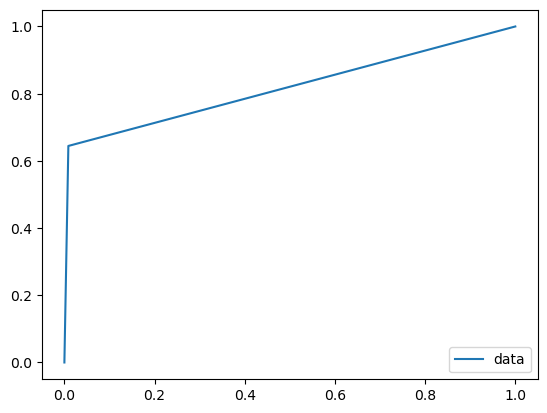

In [17]:
fpr,tpr,_=metrics.roc_curve(y_test,y_pred)
plt.plot(fpr,tpr,label="data")
plt.legend(loc=4)
plt.show()

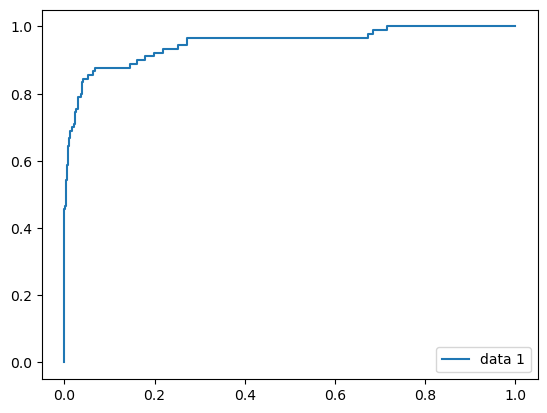

In [18]:
y_pred_proba=logreg.predict_proba(x_test)[::,1]
fpr,tpr,_=metrics.roc_curve(y_test,y_pred_proba)
plt.plot(fpr,tpr,label="data 1")
plt.legend(loc=4)
plt.show()

In [19]:
logreg.intercept_

array([-9.9226204])

In [20]:
logreg.coef_

array([[-0.4715402 ,  0.7063772 , 10.54315731,  0.044866  ,  1.82528884,
         1.68185245,  3.32598227,  0.68001298, -0.69874987,  3.52580533,
        -0.69769498, -1.01429847]])

In [21]:
logreg.predict_proba(x)

array([[9.98481823e-01, 1.51817705e-03],
       [9.99575979e-01, 4.24020742e-04],
       [9.99924340e-01, 7.56598829e-05],
       ...,
       [9.92621515e-01, 7.37848475e-03],
       [9.95533481e-01, 4.46651903e-03],
       [9.98596626e-01, 1.40337447e-03]])

In [22]:
logreg.predict(x)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [23]:
logreg.score(x,y)

0.953

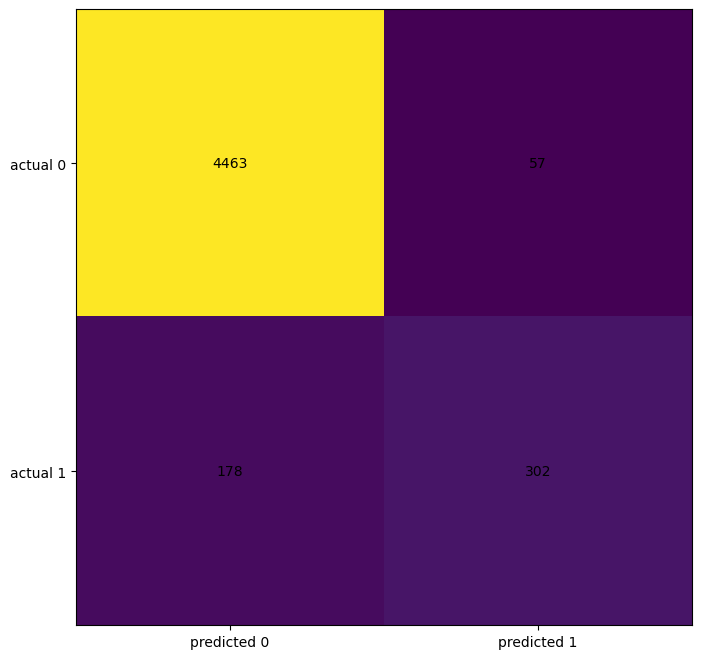

In [24]:
cm=confusion_matrix(y,logreg.predict(x))

fig,ax=plt.subplots(figsize=(8,8))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1),ticklabels=("predicted 0","predicted 1"))
ax.yaxis.set(ticks=(0,1),ticklabels=("actual 0","actual 1"))
ax.set_ylim(1.5,-0.5)
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",color="black")
    
plt.show()

In [25]:
print(classification_report(y,logreg.predict(x)))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4520
           1       0.84      0.63      0.72       480

    accuracy                           0.95      5000
   macro avg       0.90      0.81      0.85      5000
weighted avg       0.95      0.95      0.95      5000



In [26]:
df2=pd.DataFrame(df1)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [27]:
df2['CCAvg'] = df1['CCAvg'].astype(int)

In [28]:
Income2=df2["Income"]**2
CCAvg2=df2["CCAvg"]**2
Mortgage2=df2["Mortgage"]**2
Education2=df2["Education"]**2

In [29]:
df2.insert(13,"Income2",Income2)
df2.insert(14,"CCAvg2",CCAvg2)
df2.insert(15,"Mortgage2",Mortgage2)
df2.insert(16,"Education2",Education2)

In [30]:
inco_cd=df2["CD Account"]*df2["Income2"]
inco_mort=df2["Mortgage2"]*df2["Income2"]
incom_ccav=df2["Income"]*df2["CCAvg"]
incom_edu=df2["Education2"]*df2["Income2"]
incom_famil=df2["Income"]*df2["Family"]
mort2_edu2=df2["Mortgage2"]*df2["Education2"]
family_edu2=df2["Family"]*df2["Education2"]
age_exp=df2["Age"]*df2["Experience"]


In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 5000 non-null   int64
 1   Experience          5000 non-null   int64
 2   Income              5000 non-null   int64
 3   ZIP Code            5000 non-null   int64
 4   Family              5000 non-null   int64
 5   CCAvg               5000 non-null   int32
 6   Education           5000 non-null   int64
 7   Mortgage            5000 non-null   int64
 8   Personal Loan       5000 non-null   int64
 9   Securities Account  5000 non-null   int64
 10  CD Account          5000 non-null   int64
 11  Online              5000 non-null   int64
 12  CreditCard          5000 non-null   int64
 13  Income2             5000 non-null   int64
 14  CCAvg2              5000 non-null   int32
 15  Mortgage2           5000 non-null   int64
 16  Education2          5000 non-null   int64


In [32]:
df2.insert(17,"inco_cd",inco_cd)
df2.insert(18,"inco_mort",inco_mort)
df2.insert(19,"incom_ccav",incom_ccav)
df2.insert(20,"incom_edu",incom_edu)
df2.insert(21,"incom_famil",incom_famil)
df2.insert(22,"mort2_edu2",mort2_edu2)
df2.insert(23,"family_edu2",family_edu2)
df2.insert(24,"age_exp",age_exp)

In [33]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 5000 non-null   int64
 1   Experience          5000 non-null   int64
 2   Income              5000 non-null   int64
 3   ZIP Code            5000 non-null   int64
 4   Family              5000 non-null   int64
 5   CCAvg               5000 non-null   int32
 6   Education           5000 non-null   int64
 7   Mortgage            5000 non-null   int64
 8   Personal Loan       5000 non-null   int64
 9   Securities Account  5000 non-null   int64
 10  CD Account          5000 non-null   int64
 11  Online              5000 non-null   int64
 12  CreditCard          5000 non-null   int64
 13  Income2             5000 non-null   int64
 14  CCAvg2              5000 non-null   int32
 15  Mortgage2           5000 non-null   int64
 16  Education2          5000 non-null   int64


In [34]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df2.iloc[:,[0,1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]])
norm_df2 = pd.DataFrame(norm,columns = ["Age","Experience","Income","ZIP Code","Family","CCAvg","Education",
                                        "Mortgage","Securities Account","CD Account","Online","CreditCard","Income2","CCAvg2","Mortgage2","Education2","inco_cd","inco_mort","incom_ccav","incom_edu",
                                        "incom_famil","mort2_edu2","family_edu2","age_exp"])
norm_df2["Personal Loan"] = df2["Personal Loan"]
norm_df2.head(5)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,...,Education2,inco_cd,inco_mort,incom_ccav,incom_edu,incom_famil,mort2_edu2,family_edu2,age_exp,Personal Loan
0,0.045455,0.023256,0.189815,0.936527,1.000000,0.1,0.0,0.0,1.0,0.0,...,0.000,0.0,0.0,0.024138,0.006302,0.243523,0.0,0.085714,0.008678,0
1,0.500000,0.441860,0.120370,0.924872,0.666667,0.1,0.0,0.0,1.0,0.0,...,0.000,0.0,0.0,0.016749,0.002945,0.121762,0.0,0.057143,0.296772,0
2,0.363636,0.348837,0.013889,0.977892,0.000000,0.1,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.005419,0.000154,0.003886,0.0,0.000000,0.203054,0
3,0.272727,0.209302,0.425926,0.970931,0.000000,0.2,0.5,0.0,0.0,0.0,...,0.375,0.0,0.0,0.098522,0.107697,0.119171,0.0,0.085714,0.109337,0
4,0.272727,0.186047,0.171296,0.939080,1.000000,0.1,0.5,0.0,0.0,0.0,...,0.375,0.0,0.0,0.022167,0.021671,0.222798,0.0,0.428571,0.097188,0


In [35]:
norm_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   float64
 1   Experience          5000 non-null   float64
 2   Income              5000 non-null   float64
 3   ZIP Code            5000 non-null   float64
 4   Family              5000 non-null   float64
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   float64
 7   Mortgage            5000 non-null   float64
 8   Securities Account  5000 non-null   float64
 9   CD Account          5000 non-null   float64
 10  Online              5000 non-null   float64
 11  CreditCard          5000 non-null   float64
 12  Income2             5000 non-null   float64
 13  CCAvg2              5000 non-null   float64
 14  Mortgage2           5000 non-null   float64
 15  Education2          5000 non-null   float64
 16  inco_c

In [36]:
x=norm_df2.iloc[:,:24]
y=norm_df2["Personal Loan"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3,random_state=0)

In [37]:
logreg=LogisticRegression(solver="lbfgs",penalty="l2",random_state=0,max_iter=1000,C=4.281332398719369)
logreg.fit(x_train,y_train.ravel())
y_pred=logreg.predict(x_test)

In [38]:
logreg.score(x,y)

0.9754

In [39]:
log_loss(y_test,y_pred)

0.8169894768199889

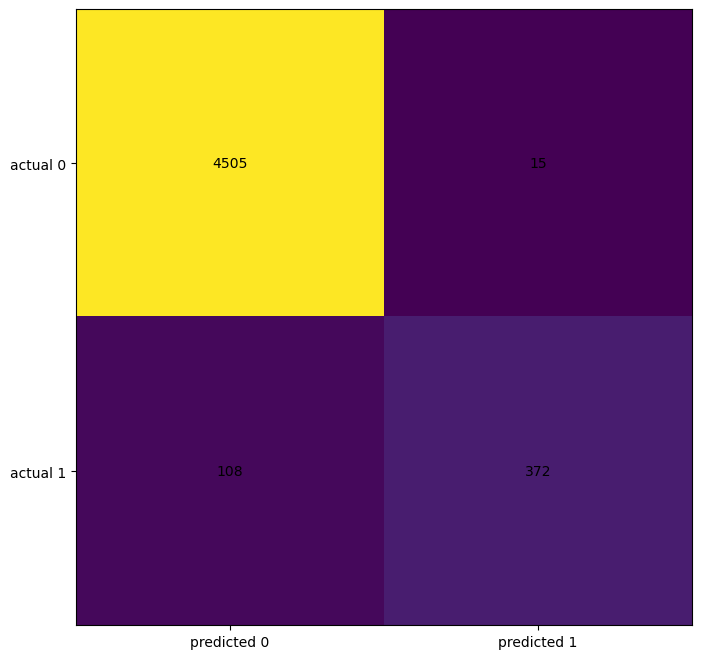

In [40]:
cm=confusion_matrix(y,logreg.predict(x))

fig,ax=plt.subplots(figsize=(8,8))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1),ticklabels=("predicted 0","predicted 1"))
ax.yaxis.set(ticks=(0,1),ticklabels=("actual 0","actual 1"))
ax.set_ylim(1.5,-0.5)
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",color="black")
    
plt.show()

In [41]:
TP=cm[0,0]
TN=cm[1,1]
FP=cm[0,1]
FN=cm[1,0]

In [42]:
classification_error=(FP+FN)/float(TP+TN+FP+FN)
print("classification_error :{0:0.4f}".format(classification_error))

classification_error :0.0246


In [43]:
p1={"Age":42,"Experience":16,"Income":30,"ZIP Code":92037,"Family":3,"CCAvg":1.2 ,"Education":3 ,"Mortgage":0,"Personal Loan":0 ,"Securities Account":1,"CD Account": 0 ,"Online":1,"CreditCard":1}
df_test = pd.DataFrame([p1])

df_test["Income2"]=df_test["Income"]**2
df_test["CCAvg2"]=df_test["CCAvg"]**2                             
df_test["Mortgage2"]=df_test["Mortgage"]**2          
df_test["Education2"]= df_test["Education"]**2
df_test["inco_cd"]=df_test["Income2"]*df_test["CD Account"]
df_test["inco_mort"]=df_test["Income2"]*df_test["Mortgage2"]
df_test["incom_ccav"]=df_test["Income"]*df_test["CCAvg"]
df_test["incom_edu"]= df_test["Income2"]*df_test["Education2"]
df_test["incom_famil"]=df_test["Income"]*df_test["Family"] 
df_test["mort2_edu2"]=df_test["Mortgage2"]*df_test["Education2"]
df_test["family_edu2"]=df_test["Family"]*df_test["Education2"]
df_test["age_exp"]=df_test["Age"]*df_test["Experience"]


In [44]:
df3 = df2.append([df_test],ignore_index=True)
df3

C:\Users\Raya_Bit\AppData\Local\Temp\ipykernel_11920\3343835452.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df3 = df2.append([df_test],ignore_index=True)


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Mortgage2,Education2,inco_cd,inco_mort,incom_ccav,incom_edu,incom_famil,mort2_edu2,family_edu2,age_exp
0,25,1,49,91107,4,1.0,1,0,0,1,...,0,1,0,0,49.0,2401,196,0,4,25
1,45,19,34,90089,3,1.0,1,0,0,1,...,0,1,0,0,34.0,1156,102,0,3,855
2,39,15,11,94720,1,1.0,1,0,0,0,...,0,1,0,0,11.0,121,11,0,1,585
3,35,9,100,94112,1,2.0,2,0,0,0,...,0,4,0,0,200.0,40000,100,0,4,315
4,35,8,45,91330,4,1.0,2,0,0,0,...,0,4,0,0,45.0,8100,180,0,16,280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,30,4,15,92037,4,0.0,1,85,0,0,...,7225,1,0,1625625,0.0,225,60,7225,4,120
4997,63,39,24,93023,2,0.0,3,0,0,0,...,0,9,0,0,0.0,5184,48,0,18,2457
4998,65,40,49,90034,3,0.0,2,0,0,0,...,0,4,0,0,0.0,9604,147,0,12,2600
4999,28,4,83,92612,3,0.0,1,0,0,0,...,0,1,0,0,0.0,6889,249,0,3,112


In [45]:
print("show missing value :",df3.isnull().sum())

show missing value : Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
Income2               0
CCAvg2                0
Mortgage2             0
Education2            0
inco_cd               0
inco_mort             0
incom_ccav            0
incom_edu             0
incom_famil           0
mort2_edu2            0
family_edu2           0
age_exp               0
dtype: int64


In [46]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5001 non-null   int64  
 1   Experience          5001 non-null   int64  
 2   Income              5001 non-null   int64  
 3   ZIP Code            5001 non-null   int64  
 4   Family              5001 non-null   int64  
 5   CCAvg               5001 non-null   float64
 6   Education           5001 non-null   int64  
 7   Mortgage            5001 non-null   int64  
 8   Personal Loan       5001 non-null   int64  
 9   Securities Account  5001 non-null   int64  
 10  CD Account          5001 non-null   int64  
 11  Online              5001 non-null   int64  
 12  CreditCard          5001 non-null   int64  
 13  Income2             5001 non-null   int64  
 14  CCAvg2              5001 non-null   float64
 15  Mortgage2           5001 non-null   int64  
 16  Educat

In [47]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
Nt = scaler.fit_transform(df3.iloc[:,[0,1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]])
df_test1 = pd.DataFrame(Nt,columns = ["Age","Experience","Income","ZIP Code","Family","CCAvg","Education" ,
                                      "Mortgage" ,"Securities Account","CD Account","Online","CreditCard","incom2","ccavg2","Mortgage2","Education2",
                                      "incom_edu","incom_ccav","inco_mort","incom_famil","inco_cd","mort2_edu2","family_edu2","age_exp"])
df_test1["Personal Loan"]=df3["Personal Loan"]

In [48]:
x=df3.drop(["Personal Loan"],axis=1)[:5000]
y=df3[["Personal Loan"]][:5000].values.reshape(-1,1)
x_finall=df3.drop(["Personal Loan"],axis=1)[5000:]

In [49]:
logreg.fit(x,y.ravel())
y_pred=logreg.predict(x_finall)

In [50]:
y_pred

array([0], dtype=int64)